<a href="https://colab.research.google.com/github/madewitt55/cs407-regression-activities/blob/prithvi-classification/logistic_regression/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS407 In Class Activity Logistic Regression and kNN Classification**
# **Group 1**

In [2]:
import pandas as pd

df = pd.read_csv("/content/synthetic_classification_group_1.csv")

df.head()

,Synthetic_Record_ID,Hours_Studied,Attendance_Pct,Previous_GPA,Assignments_Completed,Quiz_Average,Sleep_Hours,Stress_Level,Commute_Minutes,Social_Hours,Caffeine_Cups,Split,Risk
0,G1-0001,8.46,89.95,2.55,8,72.82,6.53,4,14.24,7.95,1,train,0
1,G1-0002,5.57,79.20,1.87,7,64.08,6.17,6,22.21,6.88,1,train,0
2,G1-0003,7.58,98.91,2.63,7,81.37,8.42,2,43.86,7.58,1,train,0
3,G1-0004,5.03,72.13,2.02,6,64.85,6.04,9,12.60,7.70,4,train,1
4,G1-0005,13.92,78.51,3.13,6,81.05,6.05,5,62.46,5.73,1,train,1


# Task 1: Define the Modeling Problem

This is a binary classification problem. The goal is to predict whether a synthetic student requires academic support.

**Target (y):**
- `Risk`
- `Risk = 1` means the student requires support.
- `Risk = 0` means the student does not require support.

**Predictors (X):**
- Hours_Studied
- Attendance_Pct
- Previous_GPA
- Assignments_Completed
- Quiz_Average
- Sleep_Hours
- Stress_Level
- Commute_Minutes
- Social_Hours
- Caffeine_Cups

`Synthetic_Record_ID` is excluded because it is only an identifier.

`Split` is also excluded because it only tells us whether a row belongs to the training or test set.

In [3]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Pct",
    "Previous_GPA",
    "Assignments_Completed",
    "Quiz_Average",
    "Sleep_Hours",
    "Stress_Level",
    "Commute_Minutes",
    "Social_Hours",
    "Caffeine_Cups"
]

train_data = df["Split"] == "train"
test_data = df["Split"] == "test"

X_train = df.loc[train_data, numeric_features]
X_test = df.loc[test_data, numeric_features]

y_train = df.loc[train_data, "Risk"]
y_test = df.loc[test_data, "Risk"]

# **Task 2 — Cell 1: Check how many rows are train vs test**

In [4]:
print("Total rows:", len(df))
print("Training rows:", train_data.sum())
print("Test rows:", test_data.sum())

Total rows: 1000
Training rows: 750
Test rows: 250


In [5]:
print(df.isnull().sum())

Synthetic_Record_ID      0
Hours_Studied            0
Attendance_Pct           0
Previous_GPA             0
Assignments_Completed    0
Quiz_Average             0
Sleep_Hours              0
Stress_Level             0
Commute_Minutes          0
Social_Hours             0
Caffeine_Cups            0
Split                    0
Risk                     0
dtype: int64


In [6]:
duplicates = df["Synthetic_Record_ID"].duplicated().sum()

print("Duplicate student IDs:", duplicates)

Duplicate student IDs: 0


In [7]:
print(df.dtypes)

Synthetic_Record_ID       object
Hours_Studied            float64
Attendance_Pct           float64
Previous_GPA             float64
Assignments_Completed      int64
Quiz_Average             float64
Sleep_Hours              float64
Stress_Level               int64
Commute_Minutes          float64
Social_Hours             float64
Caffeine_Cups              int64
Split                     object
Risk                       int64
dtype: object


In [8]:
print("Training Risk proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest Risk proportions:")
print(y_test.value_counts(normalize=True))

Training Risk proportions:
Risk
0    0.629333
1    0.370667
Name: proportion, dtype: float64

Test Risk proportions:
Risk
0    0.636
1    0.364
Name: proportion, dtype: float64


In [9]:
df[numeric_features].describe()

,Hours_Studied,Attendance_Pct,Previous_GPA,Assignments_Completed,Quiz_Average,Sleep_Hours,Stress_Level,Commute_Minutes,Social_Hours,Caffeine_Cups
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.048930,81.838090,2.77135,6.87600,73.837720,7.285680,4.952000,34.725740,8.342900,3.176000
std,3.355516,9.238319,0.42831,1.58655,9.916725,0.935454,1.795249,22.307322,3.238746,2.192677
min,1.000000,53.070000,1.40000,2.00000,44.480000,4.270000,1.000000,2.000000,0.000000,0.000000
25%,6.727500,75.550000,2.47000,6.00000,67.122500,6.630000,4.000000,16.712500,5.940000,1.000000
50%,8.990000,82.015000,2.78000,7.00000,74.010000,7.225000,5.000000,30.500000,7.870000,3.000000
75%,11.335000,87.875000,3.06000,8.00000,80.640000,7.940000,6.000000,49.862500,10.625000,5.000000
max,18.840000,100.000000,4.00000,10.00000,100.000000,9.700000,10.000000,90.000000,16.000000,8.000000


In [10]:
train_test_means = df.groupby("Split")[numeric_features].mean().T

train_test_means

Split,test,train
Hours_Studied,9.63028,8.855147
Attendance_Pct,83.02628,81.442027
Previous_GPA,2.75660,2.776267
Assignments_Completed,6.84400,6.886667
Quiz_Average,73.85436,73.832173
Sleep_Hours,8.24536,6.965787
Stress_Level,4.53600,5.090667
Commute_Minutes,61.10552,25.932480
Social_Hours,12.38380,6.995933
Caffeine_Cups,6.03200,2.224000


### Train/Test Distribution Comparison

The largest differences between the training and test groups were found in Commute_Minutes, Social_Hours, Caffeine_Cups, and Sleep_Hours. The test group had much longer commute times, more social hours, higher caffeine consumption, and more sleep on average.

Other predictors such as Previous_GPA, Assignments_Completed, and Quiz_Average were very similar between the training and test groups. This shows that Group 1 contains a test population shift in several predictors.

In [11]:
for col in numeric_features:
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Hours_Studied
Min: 1.0
Max: 18.84

Attendance_Pct
Min: 53.07
Max: 100.0

Previous_GPA
Min: 1.4
Max: 4.0

Assignments_Completed
Min: 2
Max: 10

Quiz_Average
Min: 44.48
Max: 100.0

Sleep_Hours
Min: 4.27
Max: 9.7

Stress_Level
Min: 1
Max: 10

Commute_Minutes
Min: 2.0
Max: 90.0

Social_Hours
Min: 0.0
Max: 16.0

Caffeine_Cups
Min: 0
Max: 8


The dataset has 1,000 rows, with 750 training and 250 test rows. There are no missing values or duplicate IDs, and the numeric ranges appear reasonable. The Risk proportions are similar between train and test, but there is a population shift in predictors, especially commute time, social hours, caffeine use, and sleep.

# **Task 3 — Prepare the Predictors.**

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaler = StandardScaler()

# **Task 4: Scaled Logistic Regression.**

In this task, we are training a Logistic Regression model to predict `Risk`.

First, the data is scaled using `StandardScaler` so that all numeric predictors are on a similar scale.

Then Logistic Regression learns how each predictor is related to the chance of `Risk = 1`.

After training the model, we will look at the coefficients and odds ratios.

A positive coefficient means the predictor is associated with a higher chance of `Risk = 1`.

A negative coefficient means the predictor is associated with a lower chance of `Risk = 1`.

The model is trained only on the training data.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

coefficients = logistic_model.named_steps["logistic"].coef_[0]

coef_table = pd.DataFrame({
    "Predictor": numeric_features,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

coef_table = coef_table.sort_values(
    by="Coefficient",
    ascending=False
)

coef_table

,Predictor,Coefficient,Odds_Ratio
6,Stress_Level,0.528803,1.696900
7,Commute_Minutes,0.161392,1.175146
8,Social_Hours,0.101520,1.106852
5,Sleep_Hours,-0.061197,0.940638
9,Caffeine_Cups,-0.067164,0.935042
3,Assignments_Completed,-0.366170,0.693385
4,Quiz_Average,-0.373706,0.688179
1,Attendance_Pct,-0.664120,0.514726
0,Hours_Studied,-0.688481,0.502339
2,Previous_GPA,-0.707291,0.492978


### Logistic Regression Interpretation

The Logistic Regression model shows how each predictor is associated with `Risk = 1` while holding the other predictors constant.

Because the predictors were standardized, the coefficients can be compared more fairly.

- `Stress_Level` had the strongest positive coefficient (0.529). This means higher stress was associated with a higher probability of `Risk = 1`.
- `Commute_Minutes` and `Social_Hours` also had positive coefficients, meaning higher values were associated with higher risk.
- `Previous_GPA` had the strongest negative coefficient (-0.707).
- `Hours_Studied` (-0.688) and `Attendance_Pct` (-0.664) also had strong negative coefficients. Higher values were associated with a lower probability of `Risk = 1`.
- `Sleep_Hours` and `Caffeine_Cups` had coefficients close to zero, so their relationships with Risk were relatively weak in this model.

The odds ratios tell the same story. For example, the odds ratio for `Stress_Level` is about 1.70, meaning a one-standard-deviation increase in stress is associated with higher odds of `Risk = 1`, while holding the other predictors constant.

These results describe associations in the synthetic dataset and should not be interpreted as causal relationships.

## Task 5: Tune Scaled kNN

In this task, we are training a k-nearest neighbors classification model.

kNN predicts a student's Risk by looking at the most similar students in the training data and letting those nearby students vote.

The value of `k` tells the model how many neighbors to look at.

For example:

- `k = 3` means look at the 3 closest students.
- `k = 5` means look at the 5 closest students.
- `k = 25` means look at the 25 closest students.

We will test `k = 3, 5, 9, 15, 25`.

Each kNN model will use `StandardScaler` because kNN depends on distance and the predictors need to be on a similar scale.

We will use 5-fold stratified cross-validation on the training data only and select the value of k with the highest mean balanced accuracy.

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

k_values = [3, 5, 9, 15, 25]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=407
)

results = []

for k in k_values:
    knn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_validate(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "balanced_accuracy": "balanced_accuracy",
            "roc_auc": "roc_auc"
        }
    )

    results.append({
        "k": k,
        "Mean_Balanced_Accuracy": scores["test_balanced_accuracy"].mean(),
        "Std_Balanced_Accuracy": scores["test_balanced_accuracy"].std(),
        "Mean_ROC_AUC": scores["test_roc_auc"].mean()
    })

knn_tuning_results = pd.DataFrame(results)

knn_tuning_results

,k,Mean_Balanced_Accuracy,Std_Balanced_Accuracy,Mean_ROC_AUC
0,3,0.708212,0.013379,0.775685
1,5,0.719929,0.011495,0.800926
2,9,0.732465,0.017171,0.823835
3,15,0.739900,0.008421,0.843911
4,25,0.748730,0.017223,0.853960


### kNN Tuning Results

For this task, I tested different values of `k` to find the best setting for the k-nearest neighbors (kNN) classification model.

**kNN** predicts the Risk of a new student by finding students in the training data that are most similar to that student. These similar students are called **neighbors**. The model looks at their Risk values and uses their votes to make a prediction.

The value of **`k`** tells the model how many neighbors to look at. For example, if `k = 5`, the model looks at the 5 closest students and uses their Risk values to decide whether the new student should be predicted as `Risk = 0` or `Risk = 1`.

For this assignment, I tested the required values:

`k = 3, 5, 9, 15, and 25`.

I used **5-fold stratified cross-validation** to test each value of `k`.

**5-fold cross-validation** means that the training data is divided into 5 parts. The model trains on 4 parts and is tested on the remaining part. This process is repeated 5 times so that every part gets a chance to be used for validation.

In simple terms:

`Training data → split into 5 parts → train and test 5 different times → average the results`

The word **stratified** means that each of the 5 parts tries to keep a similar percentage of `Risk = 0` and `Risk = 1` students. This makes the comparisons between the folds more fair.

I compared each value of `k` mainly using **mean balanced accuracy**.

**Balanced accuracy** measures how well the model correctly handles both classes, `Risk = 0` and `Risk = 1`, instead of only focusing on the class that appears more often.

The word **mean** simply means average. Since each model was tested 5 times, the five balanced accuracy scores were averaged together.

The results were:

* `k = 3` had a mean balanced accuracy of about **0.708**, or **70.8%**.
* `k = 5` had a mean balanced accuracy of about **0.720**, or **72.0%**.
* `k = 9` had a mean balanced accuracy of about **0.732**, or **73.2%**.
* `k = 15` had a mean balanced accuracy of about **0.740**, or **74.0%**.
* `k = 25` had the highest mean balanced accuracy at about **0.749**, or **74.9%**.

The table also shows **Std Balanced Accuracy**. `Std` means standard deviation. This tells us how much the balanced accuracy changed between the 5 validation tests. A smaller value means the model's results were more consistent from one fold to another.

I also looked at **ROC AUC** as supporting information.

**ROC AUC** measures how well the model can separate students with `Risk = 1` from students with `Risk = 0` across different possible classification thresholds. A higher ROC AUC is generally better, with a value closer to `1.0` showing better separation between the two classes.

The ROC AUC also improved as `k` increased:

* `k = 3` had a ROC AUC of about **0.776**.
* `k = 5` had about **0.801**.
* `k = 9` had about **0.824**.
* `k = 15` had about **0.844**.
* `k = 25` had the highest ROC AUC at about **0.854**.

For this assignment, the final value of `k` must be selected using the **highest mean balanced accuracy**. Since `k = 25` had the highest mean balanced accuracy, I selected **`k = 25`** as the tuned kNN model.

This does not mean that a larger value of `k` is always better. It only means that, out of the values tested for this training dataset, `k = 25` performed the best.


## Task 6: Evaluate and Compare the Models

In this task, I will compare the final classification models using the 250 test rows that were kept separate from training.

I will compare four models:

1. **Majority-class baseline**  
   This is a very simple model that always predicts the class that appeared most often in the training data. It gives us a basic score that the machine-learning models should perform better than.

2. **Scaled Logistic Regression**  
   This is the Logistic Regression model trained earlier using standardized predictors.

3. **Scaled kNN with k = 5**  
   This uses 5 nearby students to make each prediction. The assignment requires this as a common starting point.

4. **Selected scaled kNN**  
   This uses the value of k that performed best during cross-validation. For my training data, the selected value was `k = 25`.

All final models are trained using the full training set and then evaluated on the untouched test set.

The classification threshold is `0.50`. This means that if the model gives a student a probability of at least 50% for `Risk = 1`, the prediction becomes `Risk = 1`. Otherwise, the prediction becomes `Risk = 0`.

I will compare the models using accuracy, balanced accuracy, precision, recall, F1 score, ROC AUC, and average precision.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Find the best k from Task 5
best_k = int(
    knn_tuning_results.loc[
        knn_tuning_results["Mean_Balanced_Accuracy"].idxmax(),
        "k"
    ]
)

# Majority-class baseline
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

# kNN with k = 5
knn_5_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_5_model.fit(X_train, y_train)

# Selected kNN model
selected_knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

selected_knn_model.fit(X_train, y_train)

# Models to compare
models = {
    "Majority Baseline": baseline_model,
    "Logistic Regression": logistic_model,
    "kNN k=5": knn_5_model,
    f"kNN k={best_k}": selected_knn_model
}

results = []

for name, model in models.items():

    # Probability of Risk = 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Turn probability into 0 or 1 using threshold = 0.50
    y_pred = (y_prob >= 0.50).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Average_Precision": average_precision_score(y_test, y_prob)
    })

comparison_table = pd.DataFrame(results)

comparison_table

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Average_Precision
0,Majority Baseline,0.636,0.500000,0.000000,0.000000,0.000000,0.500000,0.364000
1,Logistic Regression,0.840,0.817817,0.807229,0.736264,0.770115,0.899509,0.847841
2,kNN k=5,0.788,0.748739,0.763889,0.604396,0.674847,0.840417,0.737637
3,kNN k=25,0.804,0.747218,0.875000,0.538462,0.666667,0.881713,0.811875


### Model Evaluation and Comparison

For this task, I evaluated all four models on the 250 test rows that were kept separate from training.

I compared the Majority-Class Baseline, Logistic Regression, kNN with `k = 5`, and the selected kNN model with `k = 25`.

The **majority-class baseline** always predicts the most common class from the training data, which is `Risk = 0`. It achieved an accuracy of 63.6%, but its precision, recall, and F1 score were all 0 because it never predicted any students as `Risk = 1`.

The **Logistic Regression model** had the strongest overall test performance. It achieved an accuracy of 84.0% and a balanced accuracy of about 81.8%. Its precision was about 80.7%, meaning that when the model predicted `Risk = 1`, it was correct about 80.7% of the time. Its recall was about 73.6%, meaning it identified about 73.6% of the students who actually had `Risk = 1`.

The Logistic Regression model also had an F1 score of about 77.0% and a ROC AUC of about 90.0%, showing that it separated the two Risk classes well.

The **kNN model with `k = 5`** achieved an accuracy of 78.8% and a balanced accuracy of about 74.9%.

The selected **kNN model with `k = 25`** achieved a slightly higher overall accuracy of 80.4%, but its balanced accuracy was about 74.7%.

The `k = 25` model had a high precision of 87.5%, meaning its `Risk = 1` predictions were usually correct. However, its recall was only about 53.8%, meaning it missed many students who actually had `Risk = 1`.

Overall, Logistic Regression performed better than both kNN models on the test data. It had the highest accuracy, balanced accuracy, recall, F1 score, ROC AUC, and average precision.

An interesting result is that `k = 25` performed best during training cross-validation, but it did not have the highest balanced accuracy on the final test data. This may be related to Group 1's test population shift, because the test students have different predictor distributions from the training students.


### Confusion Matrices and ROC Curve

To better understand the models, I also created confusion matrices and an ROC curve.

A **confusion matrix** shows the actual class compared with what the model predicted.

It includes four possible results:

* **True Negative (TN):** The student was actually `Risk = 0`, and the model correctly predicted `Risk = 0`.
* **True Positive (TP):** The student was actually `Risk = 1`, and the model correctly predicted `Risk = 1`.
* **False Positive (FP):** The student was actually `Risk = 0`, but the model incorrectly predicted `Risk = 1`.
* **False Negative (FN):** The student was actually `Risk = 1`, but the model incorrectly predicted `Risk = 0`.

The confusion matrices help show what kinds of mistakes each model makes.

I also created an **ROC curve**. The ROC curve compares how well the models separate `Risk = 0` from `Risk = 1` across different classification thresholds.

A model with a curve closer to the top-left corner and an ROC AUC closer to `1.0` has better separation between the two classes.


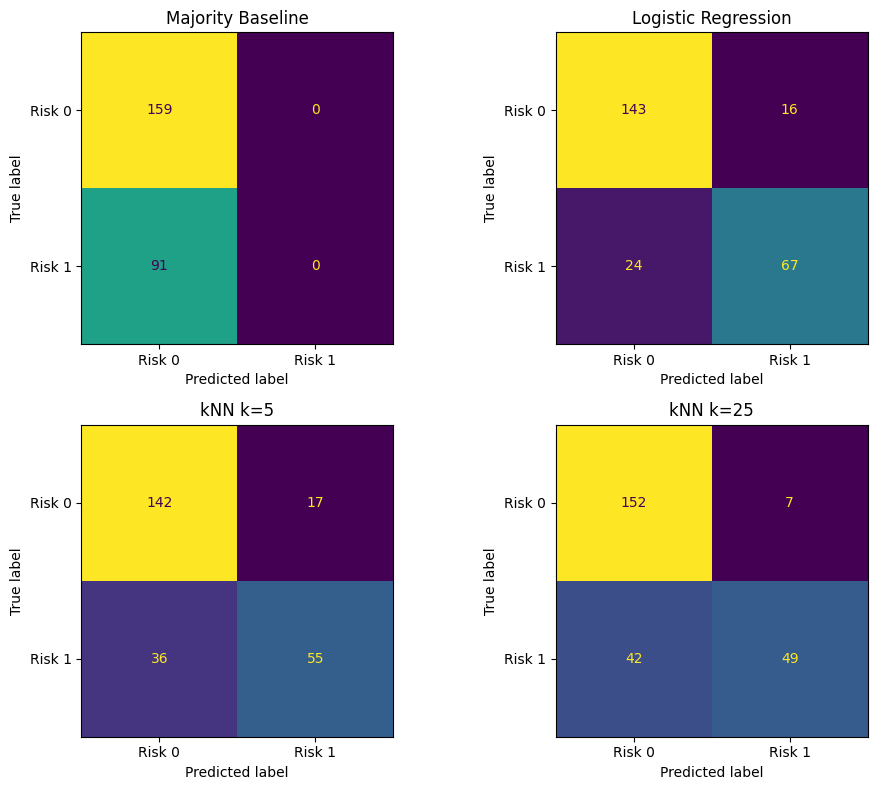

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Risk 0", "Risk 1"]
    )

    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

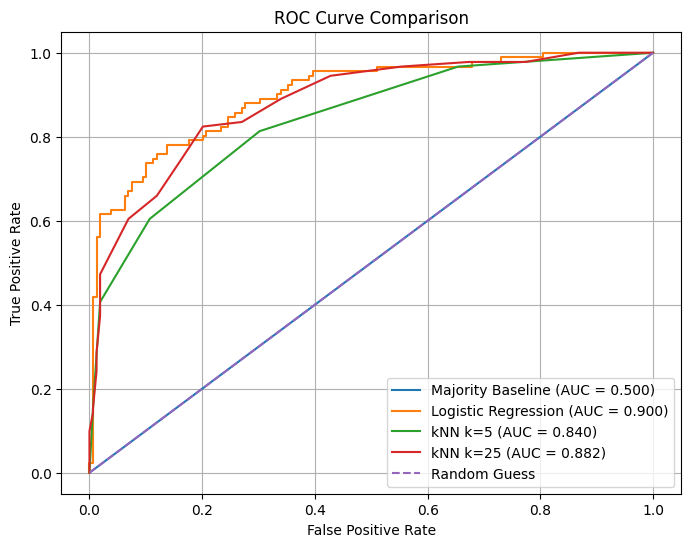

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

### ROC Curve Interpretation

The ROC curve shows how well each model can separate students with `Risk = 1` from students with `Risk = 0`.

A model with an ROC curve closer to the top-left corner performs better. The ROC AUC score summarizes this performance into one number. A score closer to `1.0` is better, while `0.5` is similar to random guessing.

From my results:

* The Majority Baseline had an ROC AUC of about **0.500**, which is equivalent to random guessing.
* kNN with `k = 5` had an ROC AUC of about **0.840**.
* kNN with `k = 25` had an ROC AUC of about **0.882**.
* Logistic Regression had the highest ROC AUC at about **0.900**.

This shows that Logistic Regression did the best job of separating `Risk = 0` and `Risk = 1` students on the test data.


In [18]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=20,
    random_state=407
)

importance_table = pd.DataFrame({
    "Predictor": numeric_features,
    "Importance": perm_result.importances_mean
})

importance_table = importance_table.sort_values(
    by="Importance",
    ascending=False
)

importance_table

,Predictor,Importance
1,Attendance_Pct,0.061984
0,Hours_Studied,0.050591
2,Previous_GPA,0.046010
6,Stress_Level,0.032084
3,Assignments_Completed,0.026890
4,Quiz_Average,0.017510
5,Sleep_Hours,0.011226
7,Commute_Minutes,0.007305
9,Caffeine_Cups,0.004867
8,Social_Hours,0.004204


### Permutation Importance Results

For this part, I used permutation importance to see which predictors were most useful for the Logistic Regression model on the test data.

Permutation importance works by randomly mixing up one predictor at a time. If the model's balanced accuracy becomes worse after a predictor is shuffled, that predictor was important to the model.

The most important predictors were:

* `Attendance_Pct` with an importance of about **0.062**
* `Hours_Studied` with about **0.051**
* `Previous_GPA` with about **0.046**
* `Stress_Level` with about **0.032**
* `Assignments_Completed` with about **0.027**

This means the model depended the most on attendance, hours studied, previous GPA, and stress when making predictions.

`Commute_Minutes`, `Caffeine_Cups`, and `Social_Hours` had much smaller permutation importance values. This means changing those predictors had a smaller effect on the Logistic Regression model's test performance.

Permutation importance does not mean that a predictor causes Risk to increase or decrease. It only shows how useful that predictor was for this model's predictions.
